# Post-TARE Adoption KPIs: Bill Savings & Demand Change
**Author:** Jordan M. Joseph, PhD â€” Carnegie Mellon University

Computes bill savings ratio and electricity demand change metrics from TARE model outputs and EUSS data.

In [1]:
import os
import importlib
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from config import PROJECT_ROOT
from cmu_tare_model.constants import VALID_MENU_MPS
from cmu_tare_model.utils.load_exported_results_to_df import load_measure_package_data

from cmu_tare_model.adoption_kpis import (
    load_euss_baseline, load_euss_upgrade, mp_to_upgrade,
    compute_scenario_demand, aggregate_demand,
    compute_bill_savings_ratio, aggregate_bill_savings,
)
import cmu_tare_model.adoption_kpis.visualize_geospatial_data as _vgd
importlib.reload(_vgd)
from cmu_tare_model.adoption_kpis.visualize_geospatial_data import (
    prepare_state_geodataframe, plot_combined_choropleth,
)
from cmu_tare_model.adoption_kpis.data_loading import (
    SHAPEFILE_PATH, COUNTY_SHAPEFILE_PATH,
)

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 60)
SAVE_FIGURES = False  # Set to True to save figure files to disk

print("[OK] Imports loaded")


Project root directory: c:\users\jorda\desktop\projects\cmu-tare-model
[OK] Imports loaded


In [2]:
SELECTABLE_MPS = [mp for mp in VALID_MENU_MPS if mp != 0]

try:
    _ = input_measure_package
    batch_mode = True
    selected_mps = [int(input_measure_package)]
    print(f"BATCH MODE: Running for MP{selected_mps[0]}")
except NameError:
    batch_mode = False
    print(f"Available measure packages: {SELECTABLE_MPS}")
    mp_input = input("Enter MP numbers (comma-separated, or 'all'): ").strip()
    if mp_input.lower() == 'all':
        selected_mps = SELECTABLE_MPS
    else:
        selected_mps = [int(x.strip()) for x in mp_input.split(',') if x.strip().isdigit()]
        selected_mps = [mp for mp in selected_mps if mp in SELECTABLE_MPS]
    if not selected_mps:
        selected_mps = [4]
        print("No valid MPs selected. Defaulting to MP4.")

print(f"Selected measure packages: {selected_mps}")

Available measure packages: [3, 4]
Selected measure packages: [3, 4]


In [3]:
# Load TARE model outputs for selected measure packages.
# These contain per-building lifetime fuel costs used for bill savings ratio.

try:
    _ = DATAFRAMES_BY_MP
    print(f"DATAFRAMES_BY_MP already loaded: {list(DATAFRAMES_BY_MP.keys())}")
except NameError:
    try:
        _ = output_folder_path
        print(f"Using existing output_folder_path: {output_folder_path}")
    except NameError:
        output_folder_path = os.path.join(PROJECT_ROOT, "cmu_tare_model", "output_results")
        location_id = input("Enter location ID (e.g., 'National' or 'PA'): ").strip()
        model_run_date_time = input("Enter model run timestamp (YYYY-MM-DD_HH-MM): ").strip()

    DATAFRAMES_BY_MP = {}
    for mp in selected_mps:
        DATAFRAMES_BY_MP[mp] = load_measure_package_data(
            mp, output_folder_path, location_id, model_run_date_time
        )
    print(f"[OK] Loaded TARE data for MPs: {list(DATAFRAMES_BY_MP.keys())}")

Loading MP3 data...
  fixed_base: ✓ 
MP3 loading complete!

Loading MP4 data...
  fixed_base: ✓ 
MP4 loading complete!

[OK] Loaded TARE data for MPs: [3, 4]


In [4]:
df_baseline = load_euss_baseline()
print(f"Baseline: {len(df_baseline):,} occupied SF homes")

upgrade_data = {}
for mp in selected_mps:
    upgrade_name = mp_to_upgrade(mp)
    print(f"\nLoading MP{mp} ({upgrade_name})...")
    upgrade_data[mp] = load_euss_upgrade(upgrade_name)
    print(f"  MP{mp}: {len(upgrade_data[mp]):,} applicable homes")

print(f"\n[OK] EUSS data loaded")

Loading baseline from: c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\data\euss_data\resstock_amy2018_release_1.1\national\csv\baseline_metadata_and_annual_results.csv


c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\adoption_kpis\data_loading.py:188: DtypeWarning: Columns (61,113,121) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, index_col="bldg_id")


  After occupancy filter: 482,597 / 548,916
  After housing type filter (['Single-Family Attached', 'Single-Family Detached']): 331,531
Baseline: 331,531 occupied SF homes

Loading MP3 (upgrade03)...
Loading upgrade03 from: c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\data\euss_data\resstock_amy2018_release_1.1\national\csv\upgrade03_metadata_and_annual_results.csv


c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\adoption_kpis\data_loading.py:222: DtypeWarning: Columns (61,113,121) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, index_col="bldg_id")


  After occupancy filter: 482,597 / 548,916
  After housing type filter: 331,531
  After applicability filter: 331,526
  MP3: 331,526 applicable homes

Loading MP4 (upgrade04)...
Loading upgrade04 from: c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\data\euss_data\resstock_amy2018_release_1.1\national\csv\upgrade04_metadata_and_annual_results.csv


c:\users\jorda\desktop\projects\cmu-tare-model\cmu_tare_model\adoption_kpis\data_loading.py:222: DtypeWarning: Columns (61,113,121) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(filepath, index_col="bldg_id")


  After occupancy filter: 482,597 / 548,916
  After housing type filter: 331,531
  After applicability filter: 331,526
  MP4: 331,526 applicable homes

[OK] EUSS data loaded


In [5]:
bill_savings_geo_level = 'county'

bill_savings_results = {}
for mp in selected_mps:
    print(f"\n{'='*60}")
    print(f"BILL SAVINGS RATIO — MP{mp}, all fuels")
    print(f"{'='*60}")
    df_tare = DATAFRAMES_BY_MP[mp]['fixed_base']['inmap']
    df_ratio = compute_bill_savings_ratio(
        df_tare, mp=mp, policy_scenario='iraRef',
        fuel_filter=None, verbose=True,
        df_euss=df_baseline,
    )
    df_bill_savings_county = aggregate_bill_savings(
        df_ratio, geo_level=bill_savings_geo_level, min_home_count=10, verbose=True
    )
    bill_savings_results[mp] = df_bill_savings_county

print(f"\n[OK] Bill savings ratio complete ({bill_savings_geo_level}-level)")



BILL SAVINGS RATIO — MP3, all fuels
Per-building records (non-null ratio): 280,250
Median bill savings ratio: 0.725
Mean bill savings ratio:   0.919
Counties where median home saves money (ratio < 1): 2463 / 3098
National median of counties medians: 0.615

BILL SAVINGS RATIO — MP4, all fuels
Per-building records (non-null ratio): 280,250
Median bill savings ratio: 0.449
Mean bill savings ratio:   0.470
Counties where median home saves money (ratio < 1): 2600 / 3098
National median of counties medians: 0.391

[OK] Bill savings ratio complete (county-level)


In [ ]:
if bill_savings_geo_level == 'state':
    for mp, df_state in bill_savings_results.items():
        print(f"\n===== BILL SAVINGS RATIO (MP{mp}, NG homes) =====")
        n_savings = (df_state['median_bill_savings_ratio'] < 1.0).sum()
        print(f"States where median home saves money: {n_savings} / {len(df_state)}")
        print(f"National median: {df_state['median_bill_savings_ratio'].median():.3f}")
        print(f"\nTop 5 (best for electrification):")
        print(df_state.nsmallest(5, 'median_bill_savings_ratio')[
            ['state', 'median_bill_savings_ratio', 'total_cost_ratio', 'home_count']
        ].to_string(index=False))
        print(f"\nBottom 5 (worst for electrification):")
        print(df_state.nlargest(5, 'median_bill_savings_ratio')[
            ['state', 'median_bill_savings_ratio', 'total_cost_ratio', 'home_count']
        ].to_string(index=False))


In [6]:
demand_geo_level = 'county'

demand_results = {}
for mp in selected_mps:
    print(f"\n{'='*60}")
    print(f"DEMAND CHANGE — MP{mp}, all fuels, 100% adoption")
    print(f"{'='*60}")
    df_demand = compute_scenario_demand(
        df_baseline, upgrade_data[mp], fuel_filter=None, verbose=True,
    )
    df_demand_county = aggregate_demand(
        df_demand, geo_level=demand_geo_level, min_home_count=10, verbose=True
    )
    demand_results[mp] = df_demand_county

print(f"\n[OK] Demand change complete ({demand_geo_level}-level)")



DEMAND CHANGE — MP3, all fuels, 100% adoption

--- Demand Scenario Summary (100% adoption, all fuels) ---
Total homes: 331,526
Weighted electricity demand change:  +427,043.7 GWh (grid impact)
Weighted total site energy change:   +427,043.7 GWh (efficiency)
✓ Demand accounting check passed

--- County-Level Demand Summary ---
Counties: 3098
Total elec demand change:    +422983.0 GWh (grid impact)

DEMAND CHANGE — MP4, all fuels, 100% adoption

--- Demand Scenario Summary (100% adoption, all fuels) ---
Total homes: 331,526
Weighted electricity demand change:  +30,618.3 GWh (grid impact)
Weighted total site energy change:   +30,618.3 GWh (efficiency)
✓ Demand accounting check passed

--- County-Level Demand Summary ---
Counties: 3098
Total elec demand change:    +30292.6 GWh (grid impact)

[OK] Demand change complete (county-level)


In [ ]:
# ============================================================
# TASK 1 DIAGNOSTICS — County sample size & coverage
# ============================================================

print("=" * 65)
print("DIAGNOSTIC: Homes entering aggregation")
print("=" * 65)
print(f"fuel_filter=None confirmed: {len(df_ratio):,} homes "
      f"(expected ~331K, NOT ~181K)")
print(f"Unique counties (bill savings): {df_ratio['in.county'].nunique():,}")
print(f"Homes entering demand:          {len(df_demand):,}")
print(f"Unique counties (demand):       {df_demand['in.county'].nunique():,}")

print("\n--- County sample size distribution (demand, last MP) ---")
county_counts = df_demand.groupby('in.county').size()
print(f"Counties total:             {len(county_counts):,}")
print(f"Min / Median / Mean / Max:  "
      f"{county_counts.min()} / {county_counts.median():.0f} / "
      f"{county_counts.mean():.1f} / {county_counts.max()}")
for thresh in [5, 10, 15, 20, 30]:
    below = (county_counts < thresh).sum()
    above = (county_counts >= thresh).sum()
    print(f"  below {thresh:2d}: {below:4d}   |   at or above {thresh:2d}: {above:4d}")

print("\n--- Aggregated output coverage ---")
from cmu_tare_model.adoption_kpis import aggregate_bill_savings, aggregate_demand
for t in [5, 10, 15, 20, 30]:
    d = aggregate_demand(df_demand, geo_level='county', min_home_count=t)
    n_data = d['pct_elec_demand_change'].notna().sum()
    print(f"  min_home_count={t:2d}: {n_data:4d} counties with data")


In [ ]:
if demand_geo_level == 'state':
    for mp, df_state in demand_results.items():
        print(f"\n===== DEMAND CHANGE (MP{mp}, GWh, all fuels, 100% adoption) =====")
        print(f"Total elec demand change: {df_state['elec_change_gwh'].sum():+.1f} GWh")
        print(f"Total site energy change: {df_state['site_energy_change_gwh'].sum():+.1f} GWh")
        print(f"\nTop 5 (largest elec demand increase):")
        print(df_state[['state', 'elec_change_gwh', 'pct_elec_demand_change',
                        'site_energy_change_gwh', 'pct_site_energy_change']].head(5).to_string(index=False))
        print(f"\nBottom 5:")
        print(df_state[['state', 'elec_change_gwh', 'pct_elec_demand_change',
                        'site_energy_change_gwh', 'pct_site_energy_change']].tail(5).to_string(index=False))

In [9]:
from typing import Optional, Tuple
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap, BoundaryNorm

from cmu_tare_model.adoption_kpis.thermal_cop import assign_breakeven_category
from cmu_tare_model.adoption_kpis.data_loading import SHAPEFILE_PATH

# ============================================================================
# Load State Boundaries and Merge with Analysis Data
# ============================================================================

def prepare_state_geodataframe(
    gdf_states: gpd.GeoDataFrame,
    df_analysis: pd.DataFrame,
    merge_col: str = 'state',
    exclude_territories: Optional[list] = None
) -> Tuple[gpd.GeoDataFrame, gpd.GeoDataFrame, gpd.GeoDataFrame]:
    """
    Merge analysis results with state geometries and prepare for choropleth mapping.

    Handles different Census shapefile column naming conventions
    (STUSPS, STUSAB, STATE_ABBR) by auto-detecting the state abbreviation column.
    Reprojects to US Albers Equal Area (ESRI:102003) and splits into
    CONUS and Alaska GeoDataFrames for inset plotting.

    Args:
        gdf_states: GeoDataFrame of US state boundaries (any CRS).
        df_analysis: DataFrame with a state abbreviation column and analysis columns.
        merge_col: Column name in df_analysis containing 2-letter state abbreviations.
        exclude_territories: State/territory codes to exclude (default: PR, VI, GU, AS, MP).

    Returns:
        Tuple of (gdf_all, gdf_conus, gdf_alaska) — all in ESRI:102003.
    """
    if exclude_territories is None:
        exclude_territories = ['PR', 'VI', 'GU', 'AS', 'MP']

    # Auto-detect state abbreviation column
    state_col = None
    for col in ['STUSPS', 'STUSAB', 'STATE_ABBR']:
        if col in gdf_states.columns:
            state_col = col
            break

    if state_col is None:
        raise ValueError(
            f"No state abbreviation column found. Available columns: {list(gdf_states.columns)}"
        )

    # Reproject to US Albers Equal Area for accurate area representation
    gdf_states = gdf_states.to_crs('ESRI:102003')

    # Merge analysis data with geometries
    gdf = gdf_states.merge(
        df_analysis,
        left_on=state_col,
        right_on=merge_col,
        how='left'
    )

    # Filter: exclude territories and rows with no analysis data
    # Use the first non-id numeric column to detect missing data
    numeric_cols = df_analysis.select_dtypes(include='number').columns.tolist()
    filter_col = numeric_cols[0] if numeric_cols else merge_col

    gdf_filtered = gdf[
        (~gdf[state_col].isin(exclude_territories)) &
        (gdf[filter_col].notna())
    ].copy()

    gdf_alaska = gdf_filtered[gdf_filtered[state_col] == 'AK'].copy()
    gdf_conus = gdf_filtered[
        ~gdf_filtered[state_col].isin(['AK', 'HI'])
    ].copy()

    return gdf_filtered, gdf_conus, gdf_alaska


# ============================================================================
# Generalized Choropleth Map Function + Generate Maps
# ============================================================================

def create_choropleth_map(
    gdf_conus: gpd.GeoDataFrame,
    gdf_alaska: gpd.GeoDataFrame,
    column: str,
    title: str,
    cbar_label: str,
    year: int = 2024,
    output_path: Optional[str] = None,
    figsize: Tuple[int, int] = (16, 10),
    dpi: int = 300,
    cmap: str = 'Blues',
    norm=None,
    show_plot: bool = True
) -> Optional[str]:
    """
    Create a choropleth map with CONUS main panel and Alaska inset.

    Pass a matplotlib Normalize (e.g. TwoSlopeNorm) via `norm` for diverging
    maps; otherwise linear normalization is derived from the data automatically.
    """
    plot_kw = dict(column=column, cmap=cmap, edgecolor='black', linewidth=0.5, legend=False)

    if norm is not None:
        plot_kw['norm'] = norm
    else:
        vals = pd.concat([gdf_conus[column], gdf_alaska[column]]).dropna()
        norm = mcolors.Normalize(vmin=vals.min(), vmax=vals.max())
        plot_kw['vmin'], plot_kw['vmax'] = vals.min(), vals.max()

    fig = plt.figure(figsize=figsize, facecolor='white')
    ax_main = fig.add_axes([0.02, 0.02, 0.78, 0.90])
    ax_ak = fig.add_axes([0.02, 0.02, 0.22, 0.25])

    gdf_conus.plot(ax=ax_main, **plot_kw)
    ax_main.set_axis_off()
    ax_main.set_title(title, fontsize=20, fontweight='bold', pad=12)

    if not gdf_alaska.empty:
        gdf_alaska.plot(ax=ax_ak, **plot_kw)
    ax_ak.set_axis_off()

    # Colorbar — matplotlib handles tick placement natively for any norm
    cax = fig.add_axes([0.82, 0.08, 0.03, 0.74])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, cax=cax, label=cbar_label).ax.yaxis.label.set_fontsize(14)
    cax.tick_params(labelsize=14)

    if output_path:
        fig.savefig(output_path, dpi=dpi, bbox_inches='tight', facecolor='white')
        print(f"  Saved: {output_path}")
    if show_plot:
        plt.show()
    else:
        plt.close(fig)
    return output_path if output_path else None


# ============================================================================
# Combined Multi-MP Choropleth Figure
# ============================================================================

def plot_combined_choropleth(
    gdf_raw: gpd.GeoDataFrame,
    data_by_mp: dict,
    column: str,
    title_template: str,
    cbar_label: str,
    cmap,
    norm,
    selected_mps: list,
    figsize: Optional[Tuple[int, int]] = None,
    dpi: int = 600,
    output_path: Optional[str] = None,
    save_figure: bool = False,
    geo_level: str = 'state',
    cbar_ticks: Optional[list] = None,
) -> None:
    """Render one map panel per MP side-by-side in a single figure with a shared colorbar.

    Args:
        gdf_raw: Raw boundary GeoDataFrame (any CRS). Pass a state GeoDataFrame
            when ``geo_level='state'``, or a county GeoDataFrame (TIGER/Line with
            GEOID and STATEFP columns) when ``geo_level='county'``.
        data_by_mp: Dict mapping MP number → DataFrame with a ``state`` column
            (state level) or a ``county`` GISJOIN column (county level) plus the
            target ``column``.
        column: Column name to choropleth-shade.
        title_template: Title string with ``{mp}`` placeholder, e.g.
            ``'Thermal COP — MP{mp}'``.
        cbar_label: Colorbar axis label.
        cmap: Matplotlib colormap (name string or Colormap instance).
        norm: Matplotlib Normalize instance (e.g. ``TwoSlopeNorm``,
            ``BoundaryNorm``, ``Normalize``).
        selected_mps: Ordered list of MP keys to render as panels.
        figsize: Figure size ``(width, height)`` in inches. Defaults to
            ``(10 * n + 2, 8)`` where ``n`` is the number of MPs.
        dpi: Resolution used when saving.
        output_path: File path to save the figure. Only written when
            ``save_figure=True``.
        save_figure: If ``True`` and ``output_path`` is set, save to disk.
        geo_level: ``'state'`` (default) or ``'county'``. Controls which merge
            function is used and the polygon border linewidth (0.5 for state,
            0.1 for county — 3,000+ polygons require thin borders).
        cbar_ticks: Optional explicit tick values for the colorbar. When
            provided, overrides matplotlib's default tick placement. Useful
            with ``TwoSlopeNorm`` which can produce uneven automatic ticks.
    """
    if geo_level not in ('state', 'county'):
        raise ValueError(f"geo_level must be 'state' or 'county', got {geo_level!r}")

    n = len(selected_mps)
    if figsize is None:
        figsize = (10 * n + 2, 8)

    fig = plt.figure(figsize=figsize, facecolor='white')

    # Reserve bottom for the horizontal colorbar; maps occupy the top 81%
    map_bottom = 0.15
    map_height = 0.81

    panel_w = 0.96 / n
    gap = 0.01  # tight gap — visual spacing is dominated by map aspect ratio padding

    lw = 0.1 if geo_level == 'county' else 0.5

    # --- Pre-loop setup for county maps: CONUS base layer + state border overlay ---
    if geo_level == 'county':
        # All CONUS county geometries (reprojected, AK/HI/territories excluded)
        # → rendered as dark gray base so insufficient-data counties are visible
        # and clearly distinct from any color in the diverging colormap
        gdf_base = gdf_raw.to_crs('ESRI:102003')
        _excl = _TERRITORY_FIPS | {_ALASKA_FIPS, '15'}  # AK + HI + territories
        gdf_base_conus = gdf_base[~gdf_base['STATEFP'].isin(_excl)].copy()

        # State boundary lines — loaded once, reused across all MP panels
        _gdf_states = gpd.read_file(SHAPEFILE_PATH).to_crs('ESRI:102003')
        _sc = next(
            (c for c in ['STUSPS', 'STUSAB', 'STATE_ABBR'] if c in _gdf_states.columns),
            None,
        )
        gdf_sborder_conus = _gdf_states[
            ~_gdf_states[_sc].isin(['AK', 'HI', 'PR', 'VI', 'GU', 'AS', 'MP'])
        ].copy()

    for i, mp in enumerate(selected_mps):
        x0 = 0.02 + i * (panel_w + gap)
        w = panel_w - gap

        ax = fig.add_axes([x0, map_bottom, w, map_height])

        if geo_level == 'county':
            _, gdf_conus, _ = prepare_county_geodataframe(
                gdf_raw, data_by_mp[mp]
            )

            # Layer 1 — All CONUS counties: dark gray fill (insufficient-data base)
            gdf_base_conus.plot(
                ax=ax, color="#707070", edgecolor='#505050', linewidth=0.1
            )
            # Layer 2 — Data counties: colored fill
            gdf_conus.plot(
                ax=ax, column=column, cmap=cmap, norm=norm,
                edgecolor='#505050', linewidth=0.1, legend=False,
            )
            # Layer 3 — State borders on top
            gdf_sborder_conus.boundary.plot(
                ax=ax, edgecolor='black', linewidth=0.5, zorder=3
            )

        else:
            _, gdf_conus, _ = prepare_state_geodataframe(
                gdf_raw, data_by_mp[mp], merge_col='state'
            )
            gdf_conus.plot(
                ax=ax, column=column, cmap=cmap, norm=norm,
                edgecolor='black', linewidth=lw, legend=False,
            )

        ax.set_axis_off()
        ax.set_title(
            title_template.format(mp=mp), fontsize=20, fontweight='bold', pad=10
        )

    # Horizontal colorbar — compact, centered at the bottom
    cax = fig.add_axes([0.25, 0.04, 0.50, 0.035])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cax, orientation='horizontal', label=cbar_label)
    cbar.ax.xaxis.label.set_fontsize(18)
    cbar.ax.xaxis.set_label_position('bottom')
    cax.tick_params(labelsize=16, rotation=0)
    if cbar_ticks is not None:
        cbar.set_ticks(cbar_ticks)

    if save_figure and output_path:
        fig.savefig(output_path, dpi=dpi, bbox_inches='tight', facecolor='white')
        print(f"  Saved: {output_path}")
    plt.show()


# ============================================================================
# Load County Boundaries and Merge with Analysis Data
# ============================================================================

# Territory STATEFP codes to exclude (US Census TIGER/Line).
_TERRITORY_FIPS = {'60', '66', '69', '72', '78'}  # AS, GU, MP, PR, VI
_ALASKA_FIPS = '02'


def prepare_county_geodataframe(
    gdf_counties: gpd.GeoDataFrame,
    df_analysis: pd.DataFrame,
    county_gisjoin_col: str = 'county',
    exclude_territories: Optional[list] = None,
) -> Tuple[gpd.GeoDataFrame, gpd.GeoDataFrame, gpd.GeoDataFrame]:
    """
    Merge county-level analysis results with TIGER county geometries.

    Converts GISJOIN codes (e.g. 'G4200030') to 5-digit FIPS (e.g. '42003')
    and merges with the TIGER/Line county shapefile on the GEOID column.
    Reprojects to US Albers Equal Area (ESRI:102003) and splits into
    CONUS and Alaska GeoDataFrames for inset plotting.

    Args:
        gdf_counties: GeoDataFrame of US county boundaries loaded from
            tl_2025_us_county.shp (any CRS). Must contain GEOID and STATEFP columns.
        df_analysis: DataFrame with a county GISJOIN column and analysis columns.
        county_gisjoin_col: Column in df_analysis with GISJOIN county codes
            (e.g. 'G4200030' → FIPS '42003'). Default: 'county'.
        exclude_territories: STATEFP codes to exclude. Defaults to AS/GU/MP/PR/VI.

    Returns:
        Tuple of (gdf_all, gdf_conus, gdf_alaska) — all in ESRI:102003.
    """
    if exclude_territories is None:
        excl_fips = _TERRITORY_FIPS
    else:
        excl_fips = set(exclude_territories)

    if county_gisjoin_col not in df_analysis.columns:
        raise ValueError(
            f"Column '{county_gisjoin_col}' not found in df_analysis. "
            f"Available columns: {list(df_analysis.columns)}"
        )
    if 'GEOID' not in gdf_counties.columns:
        raise ValueError(
            f"'GEOID' column not found in county shapefile. "
            f"Available columns: {list(gdf_counties.columns)}"
        )

    # Convert GISJOIN (e.g. 'G4200030') → 5-digit FIPS (e.g. '42003')
    # GISJOIN format: G + 2-digit state FIPS + 0 + 3-digit county FIPS
    df_work = df_analysis.copy()
    df_work['GEOID'] = (
        df_work[county_gisjoin_col].str[1:3]
        + df_work[county_gisjoin_col].str[4:7]
    )

    # Reproject to US Albers Equal Area
    gdf_counties = gdf_counties.to_crs('ESRI:102003')

    # Merge analysis data with geometries
    gdf = gdf_counties.merge(df_work, on='GEOID', how='left')

    # Detect missing-data filter column
    numeric_cols = df_analysis.select_dtypes(include='number').columns.tolist()
    filter_col = numeric_cols[0] if numeric_cols else county_gisjoin_col

    gdf_filtered = gdf[
        (~gdf['STATEFP'].isin(excl_fips)) &
        (gdf[filter_col].notna())
    ].copy()

    gdf_alaska = gdf_filtered[gdf_filtered['STATEFP'] == _ALASKA_FIPS].copy()
    gdf_conus = gdf_filtered[
        ~gdf_filtered['STATEFP'].isin([_ALASKA_FIPS, '15'])  # exclude AK and HI
    ].copy()

    return gdf_filtered, gdf_conus, gdf_alaska


# ============================================================================
# Categorical Break-Even Map
# ============================================================================

BREAKEVEN_COLORS: list = ['#D32F2F', '#EF9A9A', '#90CAF9', '#1565C0']
"""Fill colors for 4 break-even favorability categories (0=Unfavorable … 3=Very Favorable)."""

BREAKEVEN_LABELS: list = ['HP does NOT beat 80% AFUE', 'HP beats 80% AFUE', 'HP beats 90% AFUE', 'HP beats 95% AFUE']
"""Display labels for the 4 break-even categories."""

def plot_categorical_breakeven_map(
    gdf_states_raw: gpd.GeoDataFrame,
    breakeven_results: dict,
    cop_results: dict,
    selected_mps: list,
    output_dir: Optional[str] = None,
    save_figure: bool = False,
    show_plot: bool = True,
) -> None:
    """Render a categorical break-even favorability map (one panel per MP).

    For each MP, merges COP results onto break-even results, calls
    :func:`assign_breakeven_category` to assign category codes 0–3, then
    plots a state-level choropleth using a ``ListedColormap`` + ``BoundaryNorm``
    with a discrete patch legend (no continuous colorbar).

    Args:
        gdf_states_raw: Raw state boundary GeoDataFrame (any CRS).
        breakeven_results: Dict mapping MP number → DataFrame returned by
            ``compute_breakeven_cop``.  Must contain ``state``,
            ``breakeven_cop_80``, ``breakeven_cop_90``, ``breakeven_cop_95``.
        cop_results: Dict mapping MP number → DataFrame returned by
            ``compute_thermal_cop``.  Must contain ``state`` and
            ``thermal_cop``.  Used to derive the ``hp_beats_breakeven_*``
            boolean columns internally — no pre-joining required.
        selected_mps: Ordered list of MP keys to render as panels.
        output_dir: Directory for saving figures.  Each MP produces one file
            named ``state_breakeven_categorical_mp{mp}_2024.png``.
        save_figure: If ``True`` and ``output_dir`` is provided, save to disk.
        show_plot: If ``True`` (default), display the figure interactively.
    """
    cmap_cat = ListedColormap(BREAKEVEN_COLORS)
    norm_cat = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap_cat.N)

    n = len(selected_mps)
    fig = plt.figure(figsize=(14 * n, 8), facecolor='white')
    panel_w = 0.88 / n
    gap = 0.02

    for i, mp in enumerate(selected_mps):
        df = breakeven_results[mp].copy()

        # Join thermal COP from cop_results
        df['thermal_cop'] = (
            cop_results[mp].set_index('state')['thermal_cop']
            .reindex(df['state'].values).values
        )

        # Derive boolean beat-columns
        df['hp_beats_breakeven_80'] = df['thermal_cop'] > df['breakeven_cop_80']
        df['hp_beats_breakeven_90'] = df['thermal_cop'] > df['breakeven_cop_90']
        df['hp_beats_breakeven_95'] = df['thermal_cop'] > df['breakeven_cop_95']

        df['be_category'] = assign_breakeven_category(df)

        x0 = 0.02 + i * (panel_w + gap)
        w = panel_w - gap

        ax = fig.add_axes([x0, 0.06, w, 0.88])

        plot_kw = dict(
            column='be_category', cmap=cmap_cat, norm=norm_cat,
            edgecolor='black', linewidth=0.5, legend=False,
        )
        _, gdf_conus, _ = prepare_state_geodataframe(
            gdf_states_raw, df, merge_col='state'
        )
        gdf_conus.plot(ax=ax, **plot_kw)
        ax.set_axis_off()
        ax.set_title(
            f'Gas Furnace vs ASHP (MP{mp}, 2024)',
            fontsize=18, fontweight='bold', pad=8,
        )

    # Shared discrete legend
    patches = [
        mpatches.Patch(color=BREAKEVEN_COLORS[i], label=BREAKEVEN_LABELS[i])
        for i in range(4)
    ]
    fig.legend(
        handles=patches, loc='lower center', ncol=4, fontsize=16,
        bbox_to_anchor=(0.5, 0.0),
    )

    if save_figure and output_dir:
        import os
        for mp in selected_mps:
            out_path = os.path.join(
                output_dir, f'state_breakeven_categorical_mp{mp}_2024.png'
            )
            fig.savefig(out_path, dpi=600, bbox_inches='tight', facecolor='white')
            print(f"  Saved: {out_path}")

    if show_plot:
        plt.show()
    else:
        plt.close(fig)


[OK] State shapefile loaded: 52 features
[OK] County shapefile loaded: 3235 features
Bill savings ratio norm: [0.187, 1.0 (center), 1.813]
Bill savings % norm: [-79.3, 0 (center), 79.3]%
Demand GWh norm: [-1158.1, 0 (center), 1158.1] GWh
Demand % norm: [-194.4, 0 (center), 194.4]%


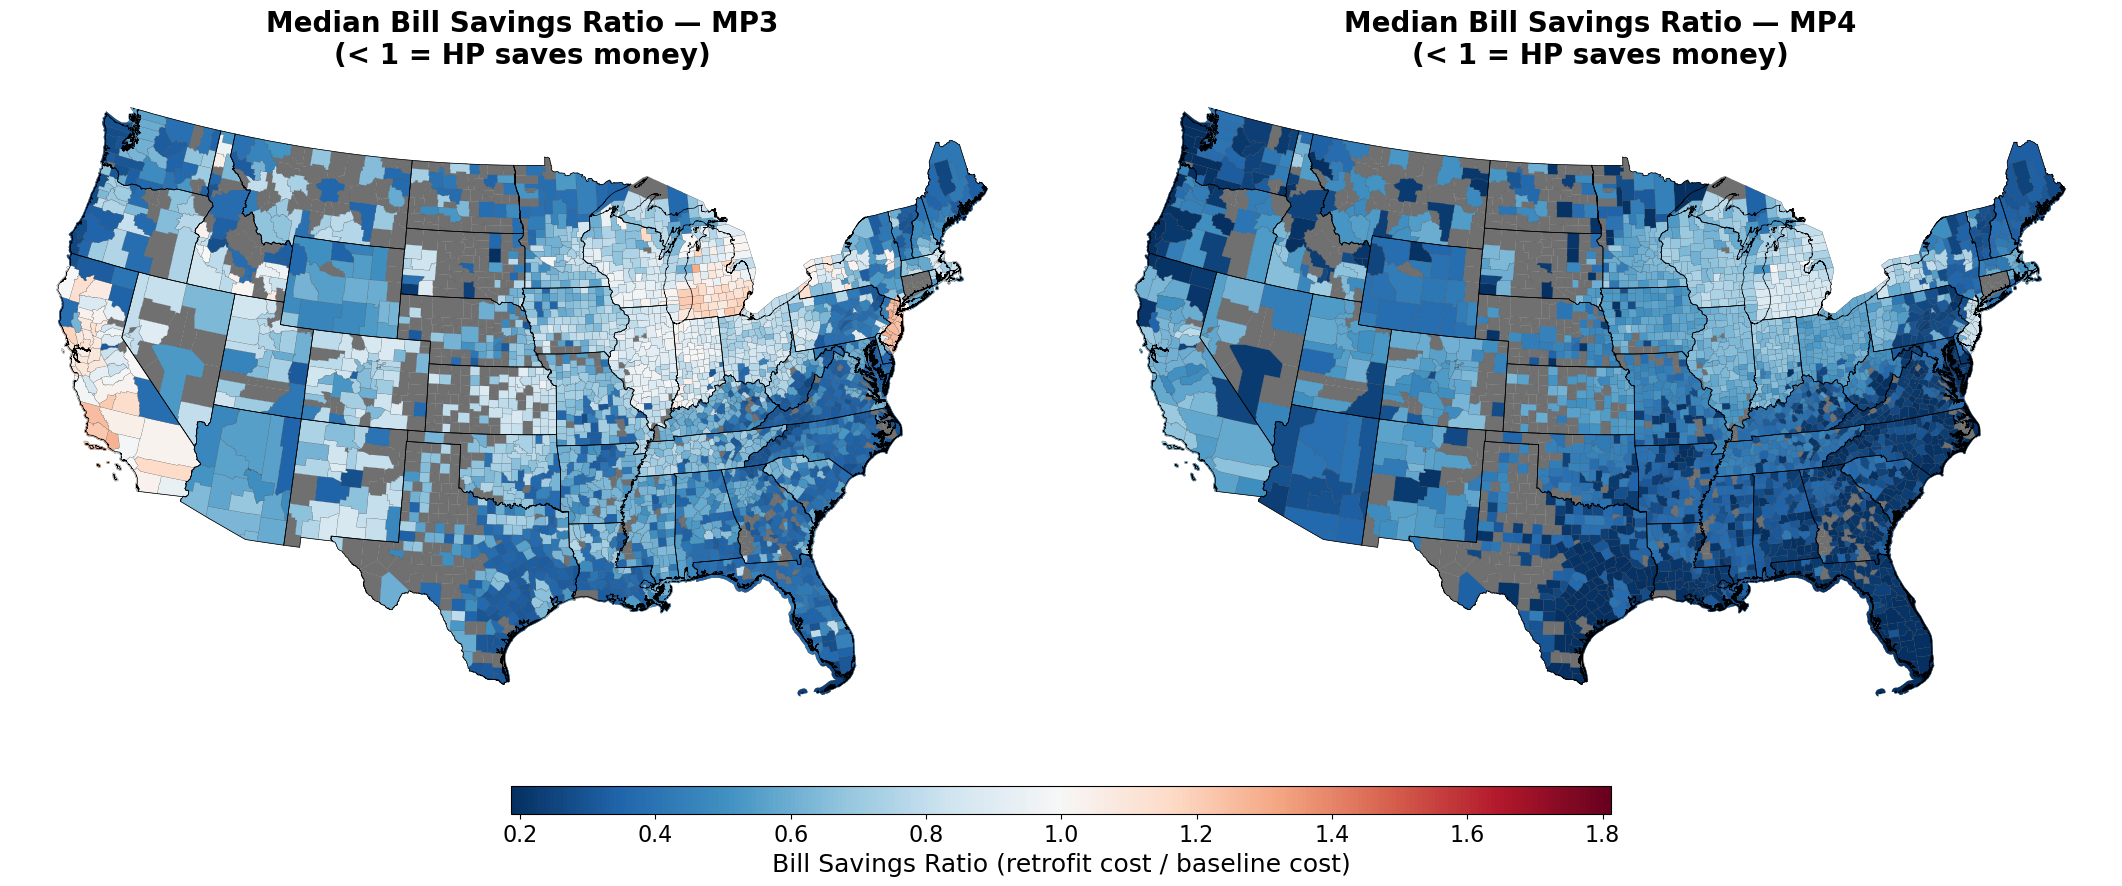

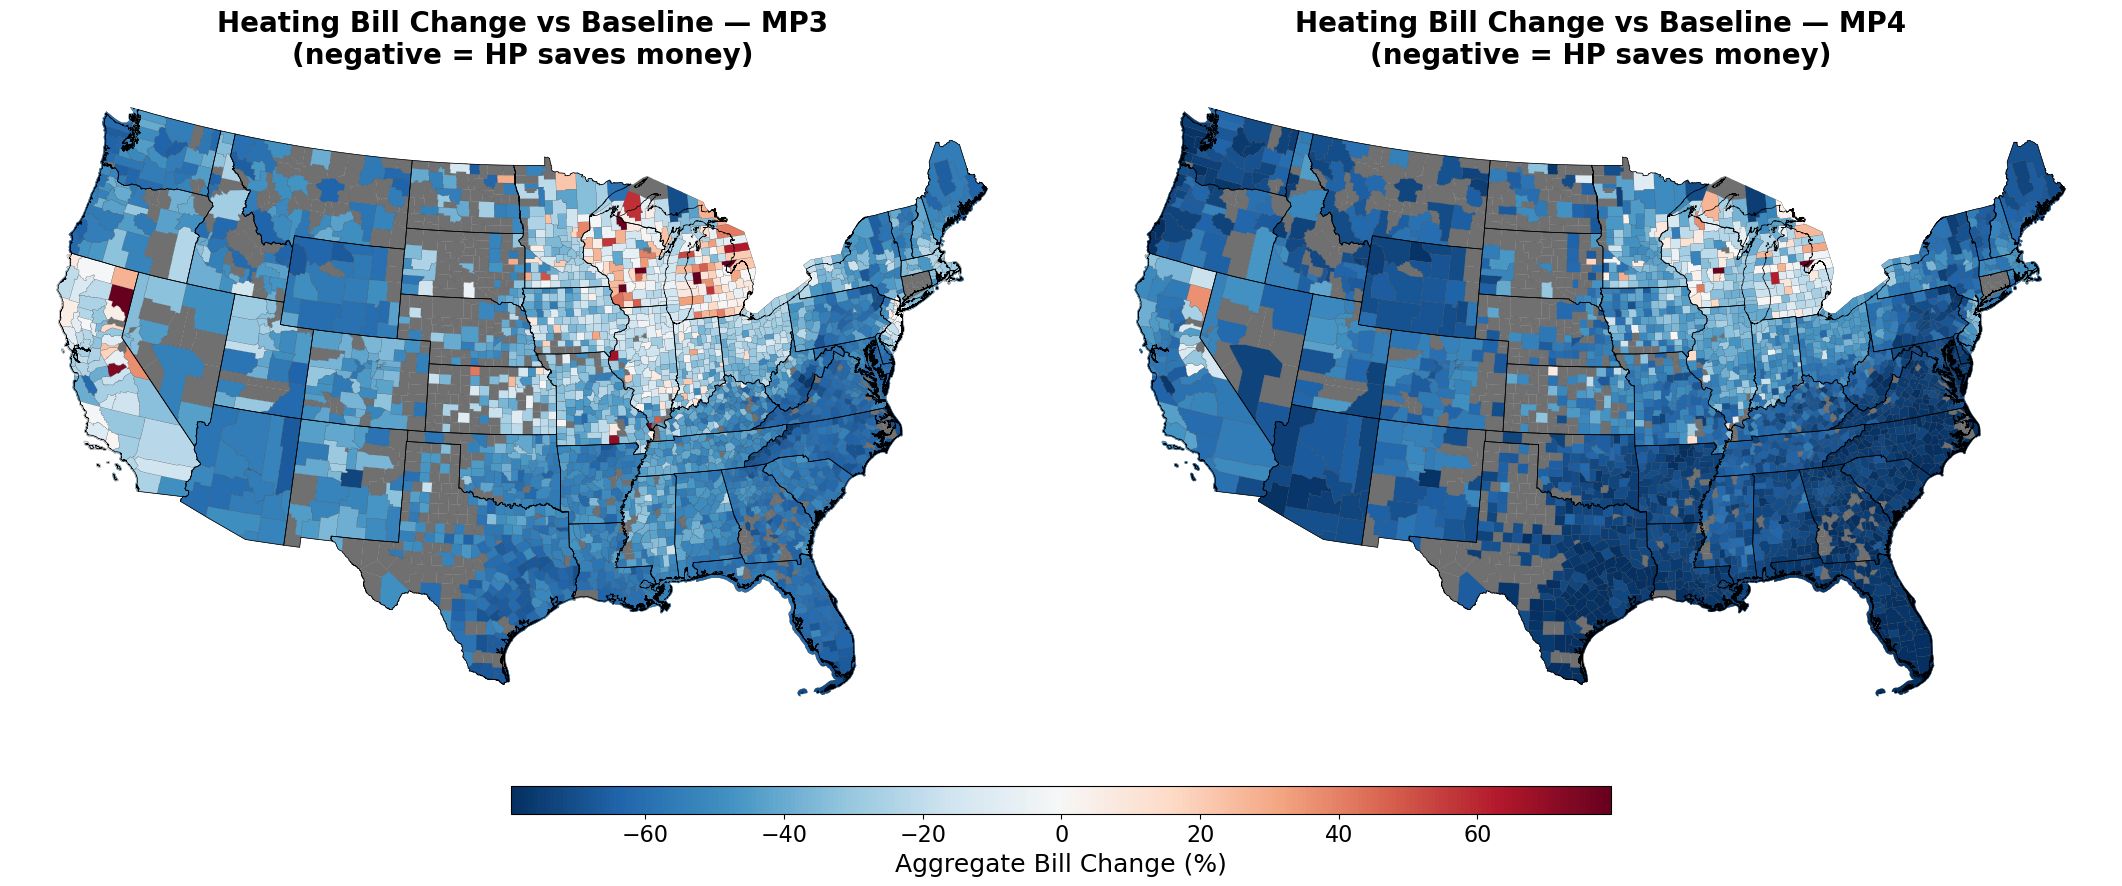

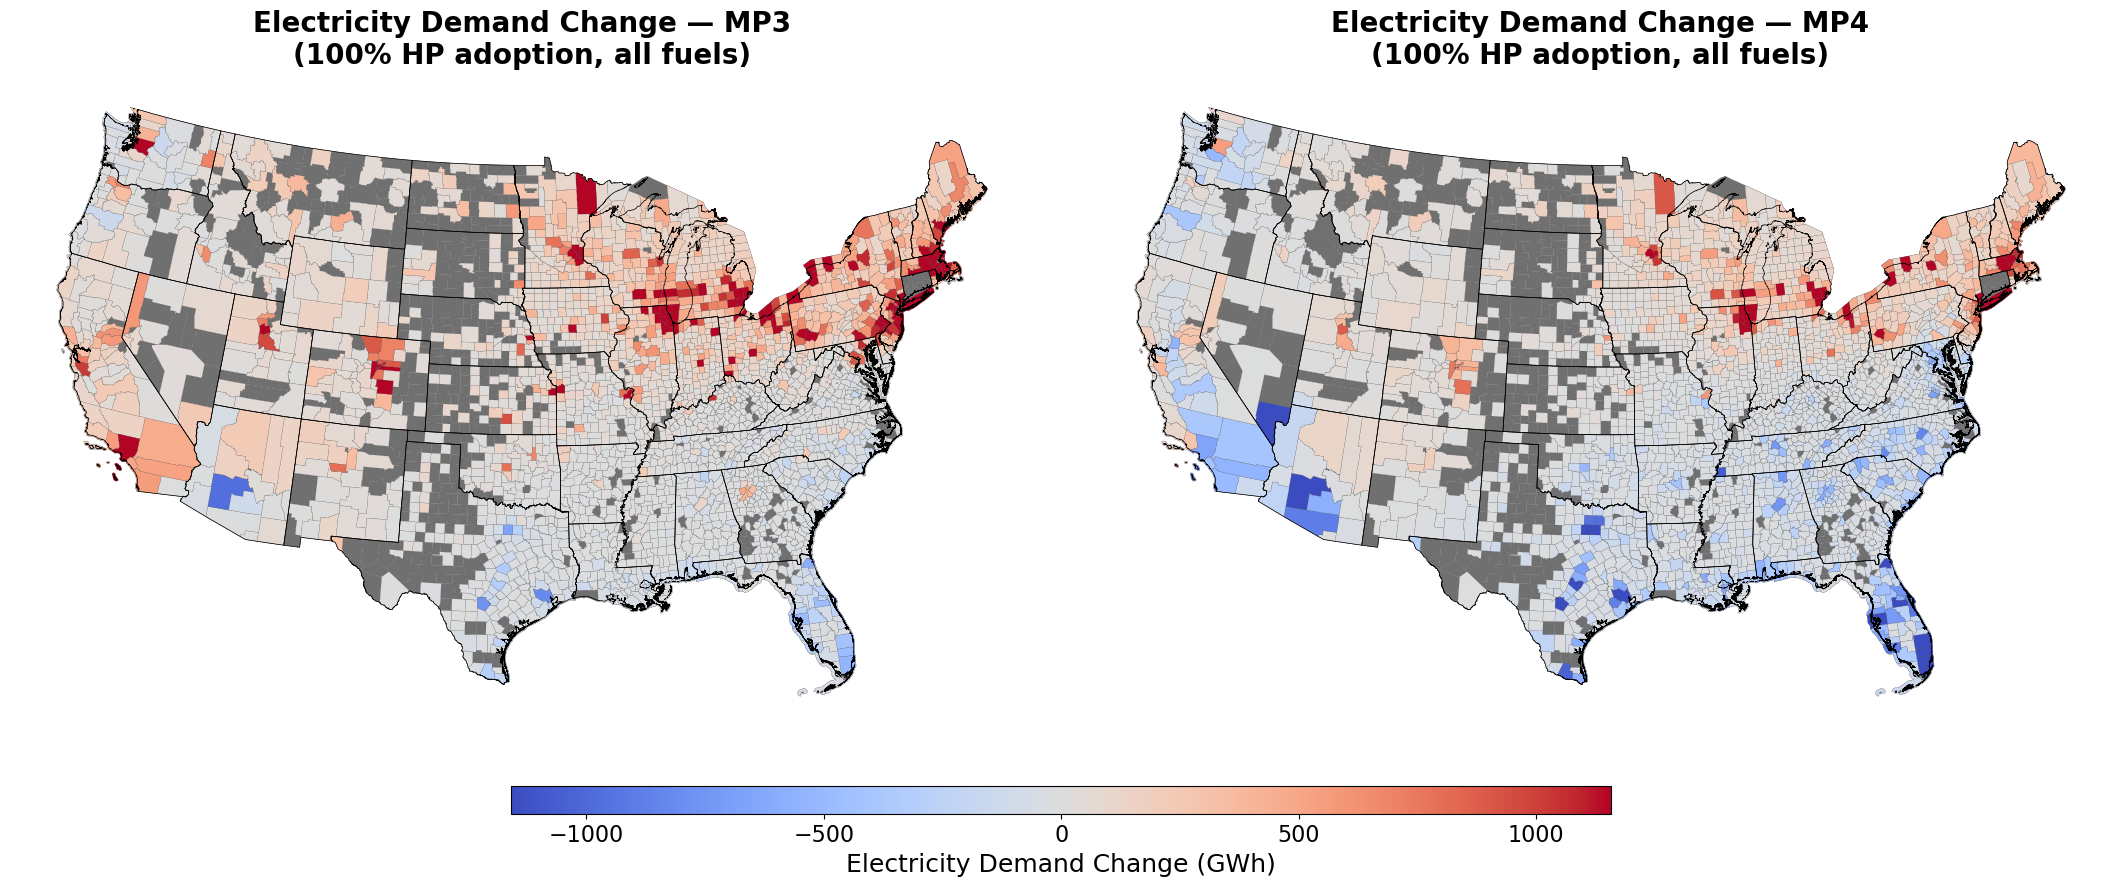

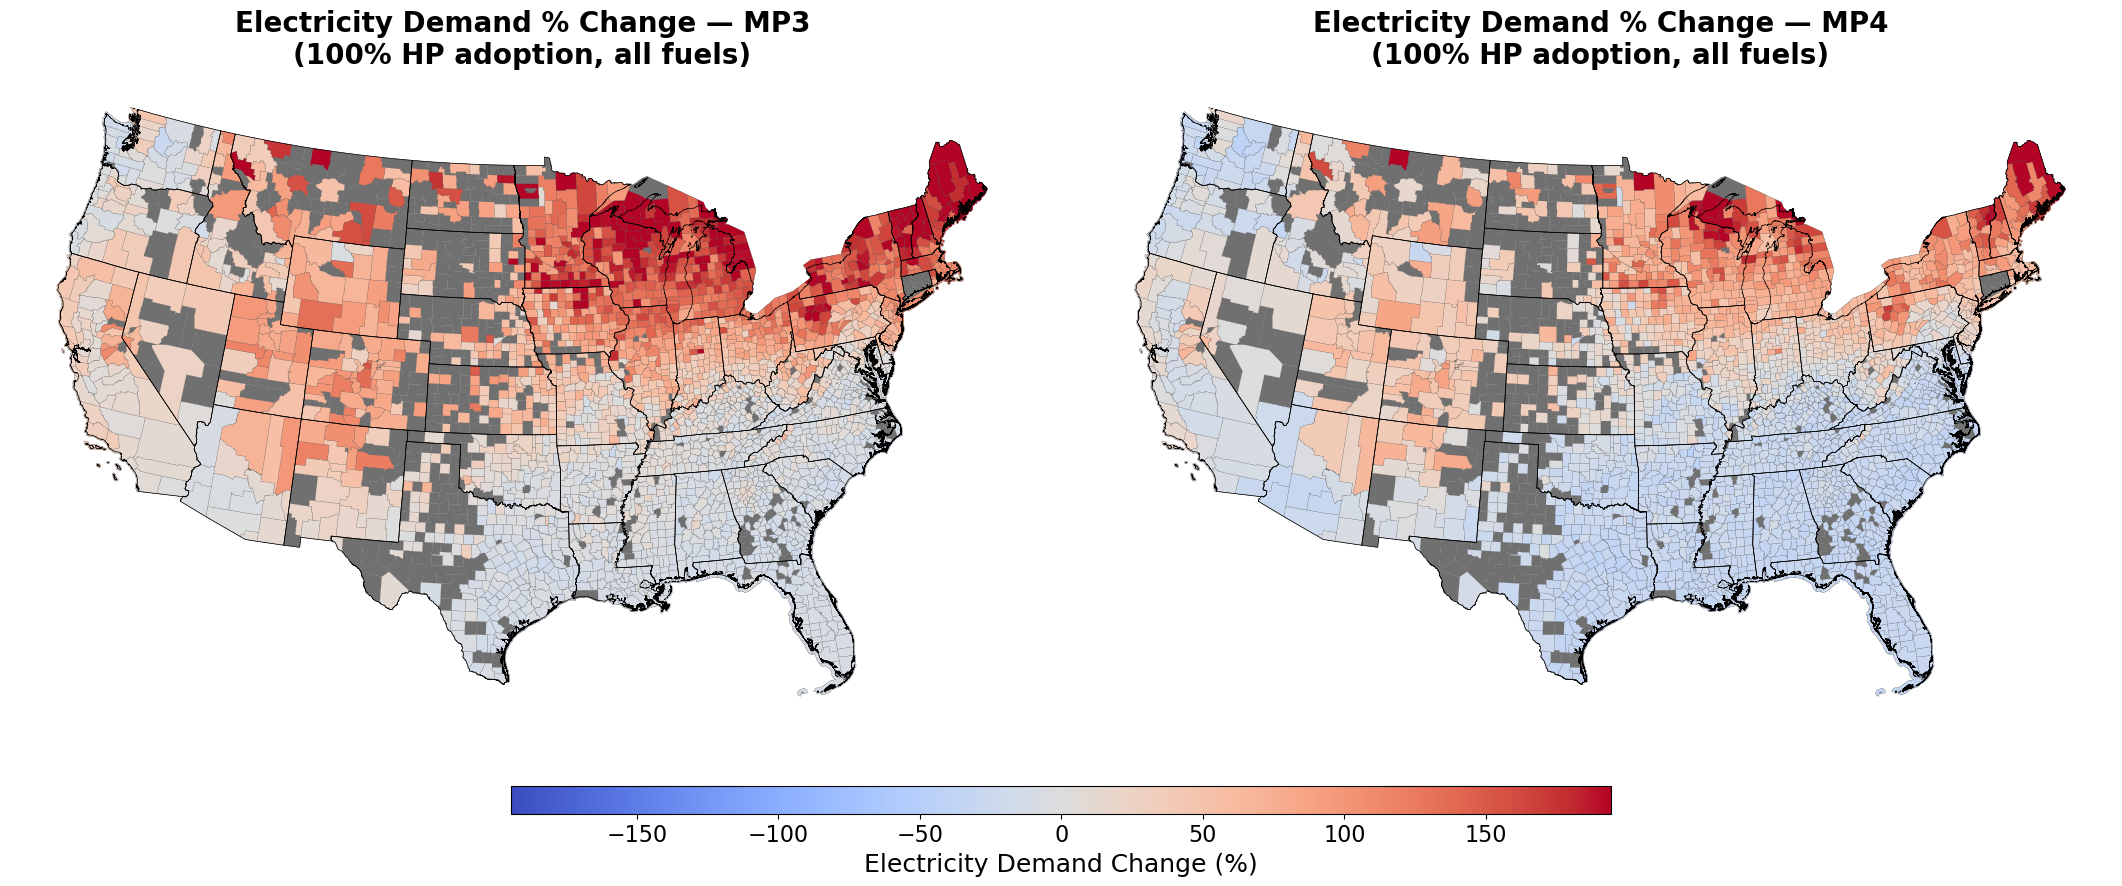

[OK] All county-level maps generated


In [10]:
from matplotlib.colors import Normalize

gdf_states_raw = None
gdf_counties_raw = None

try:
    gdf_states_raw = gpd.read_file(SHAPEFILE_PATH)
    print(f"[OK] State shapefile loaded: {len(gdf_states_raw)} features")
except Exception as e:
    print(f"[WARN] State shapefile not loaded: {e}")

try:
    gdf_counties_raw = gpd.read_file(COUNTY_SHAPEFILE_PATH)
    print(f"[OK] County shapefile loaded: {len(gdf_counties_raw)} features")
except Exception as e:
    print(f"[WARN] County shapefile not loaded: {e} — skipping county maps")

if gdf_counties_raw is not None:
    # ---- Add pct_bill_change column from total_cost_ratio ----
    # total_cost_ratio = Σ(w×retrofit_cost) / Σ(w×baseline_cost)
    # pct_bill_change  = (total_cost_ratio - 1) × 100  → aggregate % change in cost
    for mp in selected_mps:
        df = bill_savings_results[mp]
        if 'pct_bill_change' not in df.columns:
            df['pct_bill_change'] = (df['total_cost_ratio'] - 1) * 100

    # ---- Compute shared norms BEFORE any per-MP map calls ----
    # Symmetric Normalize: keeps white at the meaningful center (0 or 1.0)
    # and makes the colorbar evenly spaced on both sides.
    # Clip to 2nd/98th percentile to avoid extreme outliers compressing the scale.

    # 1. Bill savings ratio — center at 1.0
    all_ratio_vals = pd.concat([
        bill_savings_results[mp]['median_bill_savings_ratio']
        for mp in selected_mps
    ]).dropna()
    _q_low = all_ratio_vals.quantile(0.02)
    _q_high = all_ratio_vals.quantile(0.98)
    _dev = max(abs(_q_low - 1.0), abs(_q_high - 1.0))
    shared_ratio_norm = Normalize(vmin=1.0 - _dev, vmax=1.0 + _dev)
    print(f"Bill savings ratio norm: [{1.0 - _dev:.3f}, 1.0 (center), {1.0 + _dev:.3f}]")

    # 2. Bill savings percent change — center at 0
    all_pct_bill_vals = pd.concat([
        bill_savings_results[mp]['pct_bill_change']
        for mp in selected_mps
    ]).dropna()
    _q_low = all_pct_bill_vals.quantile(0.02)
    _q_high = all_pct_bill_vals.quantile(0.98)
    _abs = max(abs(_q_low), abs(_q_high))
    shared_pct_bill_norm = Normalize(vmin=-_abs, vmax=_abs)
    print(f"Bill savings % norm: [{-_abs:.1f}, 0 (center), {_abs:.1f}]%")

    # 3. Electricity demand change GWh — center at 0
    all_demand_vals = pd.concat([
        demand_results[mp]['elec_change_gwh']
        for mp in selected_mps
    ]).dropna()
    _q_low = all_demand_vals.quantile(0.02)
    _q_high = all_demand_vals.quantile(0.98)
    _abs = max(abs(_q_low), abs(_q_high))
    shared_demand_norm = Normalize(vmin=-_abs, vmax=_abs)
    print(f"Demand GWh norm: [{-_abs:.1f}, 0 (center), {_abs:.1f}] GWh")

    # 4. Electricity demand percent change — center at 0
    all_pct_demand_vals = pd.concat([
        demand_results[mp]['pct_elec_demand_change']
        for mp in selected_mps
    ]).dropna()
    _q_low = all_pct_demand_vals.quantile(0.02)
    _q_high = all_pct_demand_vals.quantile(0.98)
    _abs = max(abs(_q_low), abs(_q_high))
    shared_pct_demand_norm = Normalize(vmin=-_abs, vmax=_abs)
    print(f"Demand % norm: [{-_abs:.1f}, 0 (center), {_abs:.1f}]%")

    # ---- Map 1: Bill savings ratio (county-level) ----
    plot_combined_choropleth(
        gdf_counties_raw, bill_savings_results,
        column='median_bill_savings_ratio',
        title_template='Median Bill Savings Ratio — MP{mp}\n(< 1 = HP saves money)',
        cbar_label='Bill Savings Ratio (retrofit cost / baseline cost)',
        cmap='RdBu_r', norm=shared_ratio_norm, selected_mps=selected_mps,
        geo_level='county',
        # cbar_ticks=[0.2, 0.4, 0.6, 0.8, 1.0, 1.2, 1.4],
        save_figure=SAVE_FIGURES,
        output_path=os.path.join(PROJECT_ROOT, 'county_bill_savings_ratio_combined.png'),
    )

    # ---- Map 2: Bill savings percent change (county-level) ----
    plot_combined_choropleth(
        gdf_counties_raw, bill_savings_results,
        column='pct_bill_change',
        title_template='Heating Bill Change vs Baseline — MP{mp}\n(negative = HP saves money)',
        cbar_label='Aggregate Bill Change (%)',
        cmap='RdBu_r', norm=shared_pct_bill_norm, selected_mps=selected_mps,
        geo_level='county',
        # cbar_ticks=[-75, -50, -25, 0, 25, 50, 75],
        save_figure=SAVE_FIGURES,
        output_path=os.path.join(PROJECT_ROOT, 'county_bill_pct_change_combined.png'),
    )

    # ---- Map 3: Electricity demand change GWh (county-level) ----
    plot_combined_choropleth(
        gdf_counties_raw, demand_results,
        column='elec_change_gwh',
        title_template='Electricity Demand Change — MP{mp}\n(100% HP adoption, all fuels)',
        cbar_label='Electricity Demand Change (GWh)',
        cmap='coolwarm', norm=shared_demand_norm, selected_mps=selected_mps,
        geo_level='county',
        # cbar_ticks=[-2000, -1000, 0, 1000, 2000, 3000],
        save_figure=SAVE_FIGURES,
        output_path=os.path.join(PROJECT_ROOT, 'county_elec_demand_gwh_combined.png'),
    )

    # ---- Map 4: Electricity demand percent change (county-level) ----
    plot_combined_choropleth(
        gdf_counties_raw, demand_results,
        column='pct_elec_demand_change',
        title_template='Electricity Demand % Change — MP{mp}\n(100% HP adoption, all fuels)',
        cbar_label='Electricity Demand Change (%)',
        cmap='coolwarm', norm=shared_pct_demand_norm, selected_mps=selected_mps,
        geo_level='county',
        # cbar_ticks=[-50, -25, 0, 25, 50],
        save_figure=SAVE_FIGURES,
        output_path=os.path.join(PROJECT_ROOT, 'county_elec_demand_pct_combined.png'),
    )

    print("[OK] All county-level maps generated")
else:
    print("[WARN] County maps skipped — county shapefile not available")


In [ ]:
print("=" * 70)
print("SUMMARY")
print("=" * 70)

for mp in selected_mps:
    df_bs = bill_savings_results[mp]
    df_dem = demand_results[mp]
    n_savings = (df_bs['median_bill_savings_ratio'] < 1.0).sum()
    total_states = len(df_bs)
    nat_median_ratio = df_bs['median_bill_savings_ratio'].median()
    nat_median_pct = df_bs['pct_bill_change'].median()
    total_elec_gwh = df_dem['elec_change_gwh'].sum()
    median_pct_demand = df_dem['pct_elec_demand_change'].median()
    print(f"\n--- MP{mp} ---")
    print(f"Bill savings: {n_savings}/{total_states} states save money "
          f"| median ratio: {nat_median_ratio:.3f} "
          f"| median bill change: {nat_median_pct:+.1f}%")
    print(f"Demand change (all fuels): {total_elec_gwh:+.1f} GWh total "
          f"| median state % change: {median_pct_demand:+.1f}%")

print("\n[DONE]")
